Loaded 3 simulations from smith1_pro_t1_20260228_150742
  Iteration history rows: 3981
  Transaction rows:       105
  Rounds per sim:         5
  Total round-obs:        15

Competitive Equilibrium:
  Quantity:       6
  Price:          2.0000
  Total surplus:  7.2000
  Buyer surplus:  3.60
  Seller surplus: 3.60
  Demand:         [3.2  2.96 2.72 2.48 2.24 2.   1.76 1.52 1.28 1.04 0.8 ]
  Supply:         [0.8  1.04 1.28 1.52 1.76 2.   2.24 2.48 2.72 2.96 3.2 ]


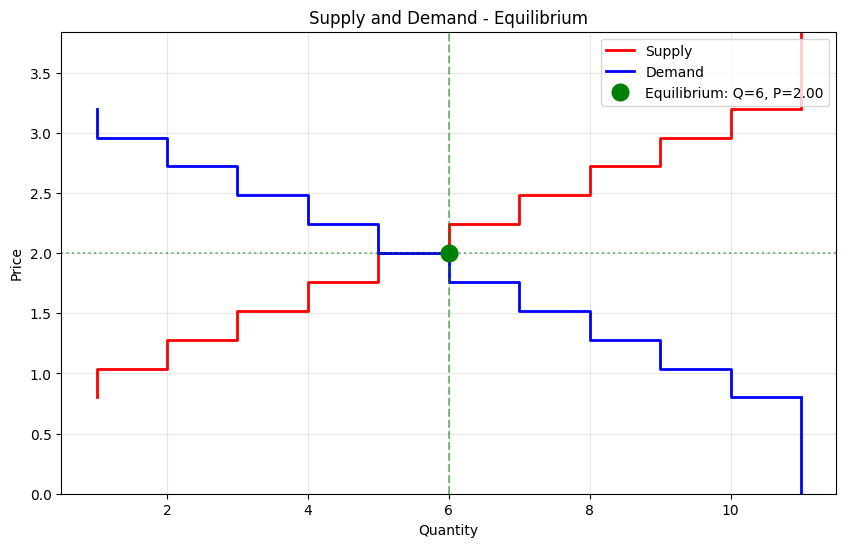


ALLOCATIVE EFFICIENCY (3 simulations × 5 rounds = 15 observations)
  Mean:   0.8933
  Median: 0.9000
  Std:    0.0632
  Min:    0.8000
  Max:    1.0000
  < 80%:  4/15
  > 90%:  7/15
  > 95%:  1/15
  = 100%: 1/15

SMITH'S ALPHA (coefficient of convergence)
  Mean:   17.20%
  Median: 16.15%
  Std:    7.16%

QUANTITY
  CE quantity:  6
  Mean trades:  7.00
  Distribution: {6: 3, 7: 9, 8: 3}

PRICE
  CE price:       2.0000
  Mean price:     1.9801
  Std of means:   0.1571

EXTRAMARGINAL ACTIVITY
  Rounds with extramarginal: 14/15 (93.3%)
  Mean extramarginal/round:  2.27
  Negative surplus trades:   0/15

EFFICIENCY PERCENTILES
  P 1: 80.0%
  P 5: 80.0%
  P10: 80.0%
  P25: 85.0%
  P50: 90.0%
  P75: 93.3%
  P90: 93.3%
  P95: 95.3%
  P99: 99.1%

ACROSS-ROUND TRAJECTORY (mean ± SEM across 3 sims)
       eff_mean  eff_sem  alpha_mean  alpha_sem  n_trades_mean
round                                                         
1        0.9111   0.0111     27.7967     3.7563         6.6667
2        0

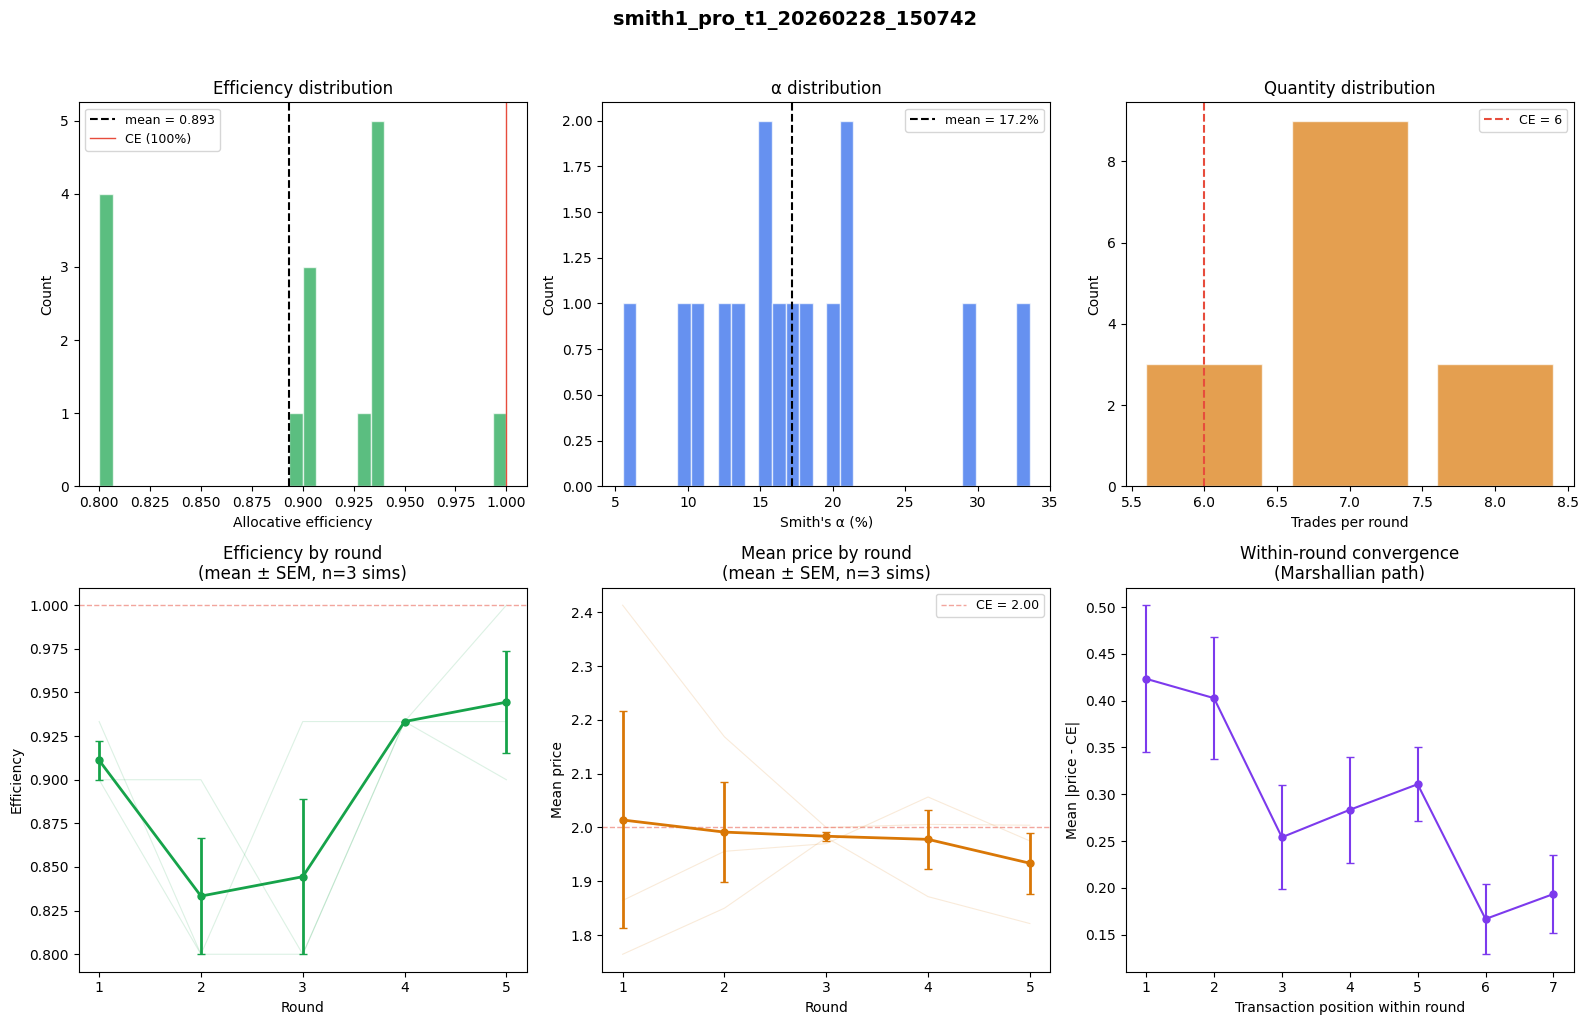

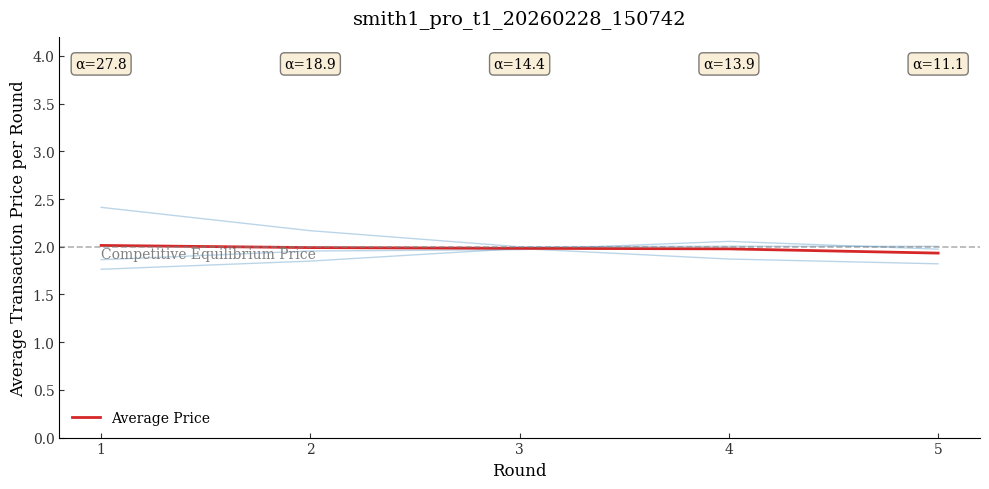


RENT-SEEKING ANALYSIS

Attempted Rent (submitted order prices):
   Buyer: mean=0.120, median=0.000, std=0.319
  Seller: mean=0.145, median=0.000, std=0.485

Realized Rent (execution prices):
  Buyer rent:  mean=0.497
  Seller rent: mean=0.422
  Buyer share:  54.9%
  Seller share: 45.1%

Concessions (submitted order prices):
   Buyer: mean concession=0.114, frac=58.8%
  Seller: mean concession=0.248, frac=64.6%

Extraction Efficiency:
   Buyer: mean=0.704, median=1.000
  Seller: mean=0.830, median=1.000

Constraint Violations:
  Announcements: 0/805 (0.0%)
  Buyer tx violations:  0/105
  Seller tx violations: 0/105

Who Trades:
  Buyer inframarginal:  84.8%
  Seller inframarginal: 82.9%
  Both inframarginal:   67.6%

Fill Rate (fraction of submitted orders that executed immediately):
   Buyer: 2.8%
  Seller: 4.1%


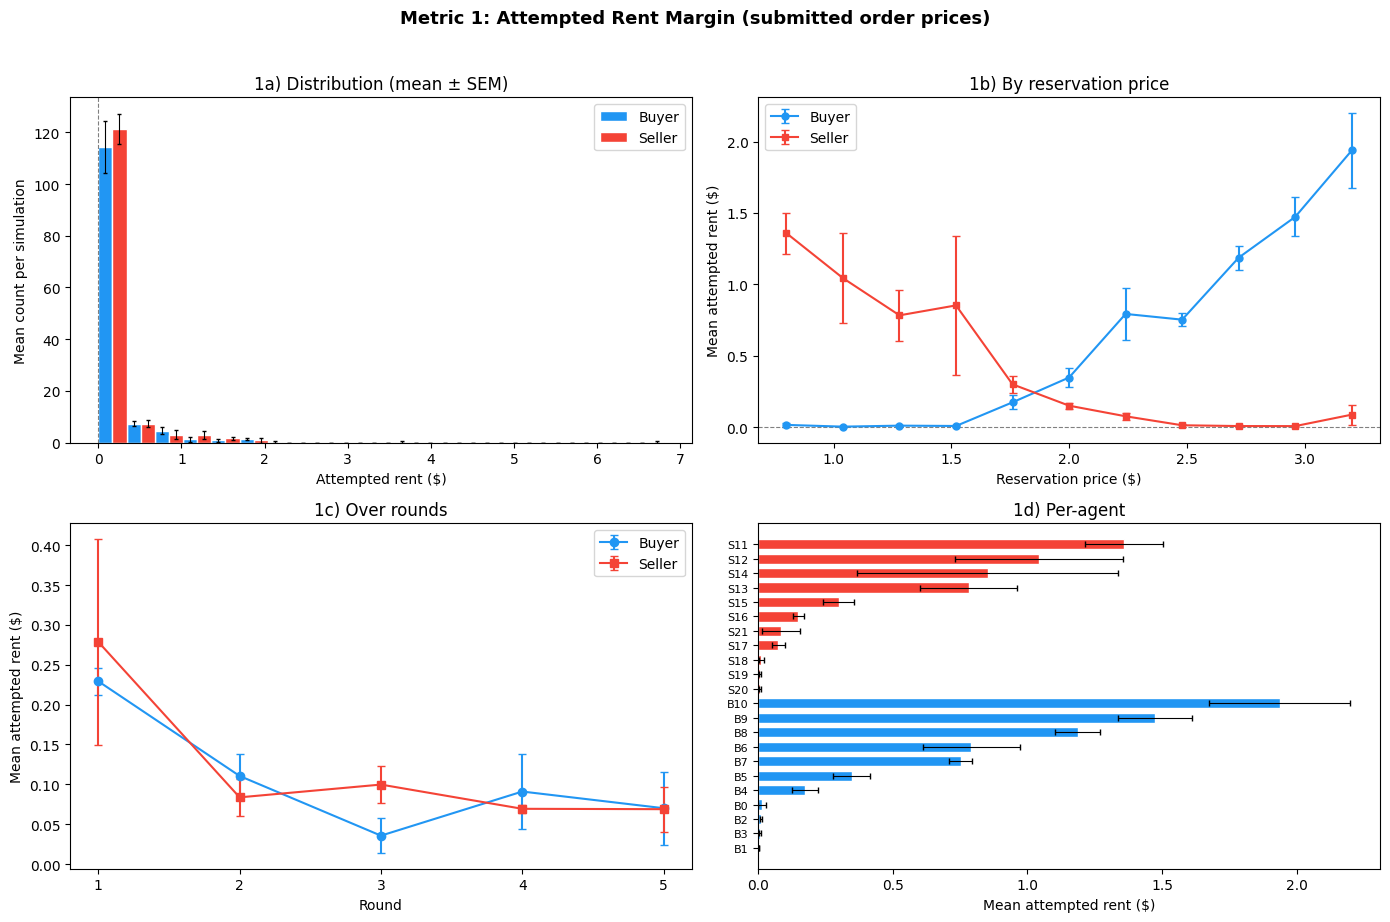

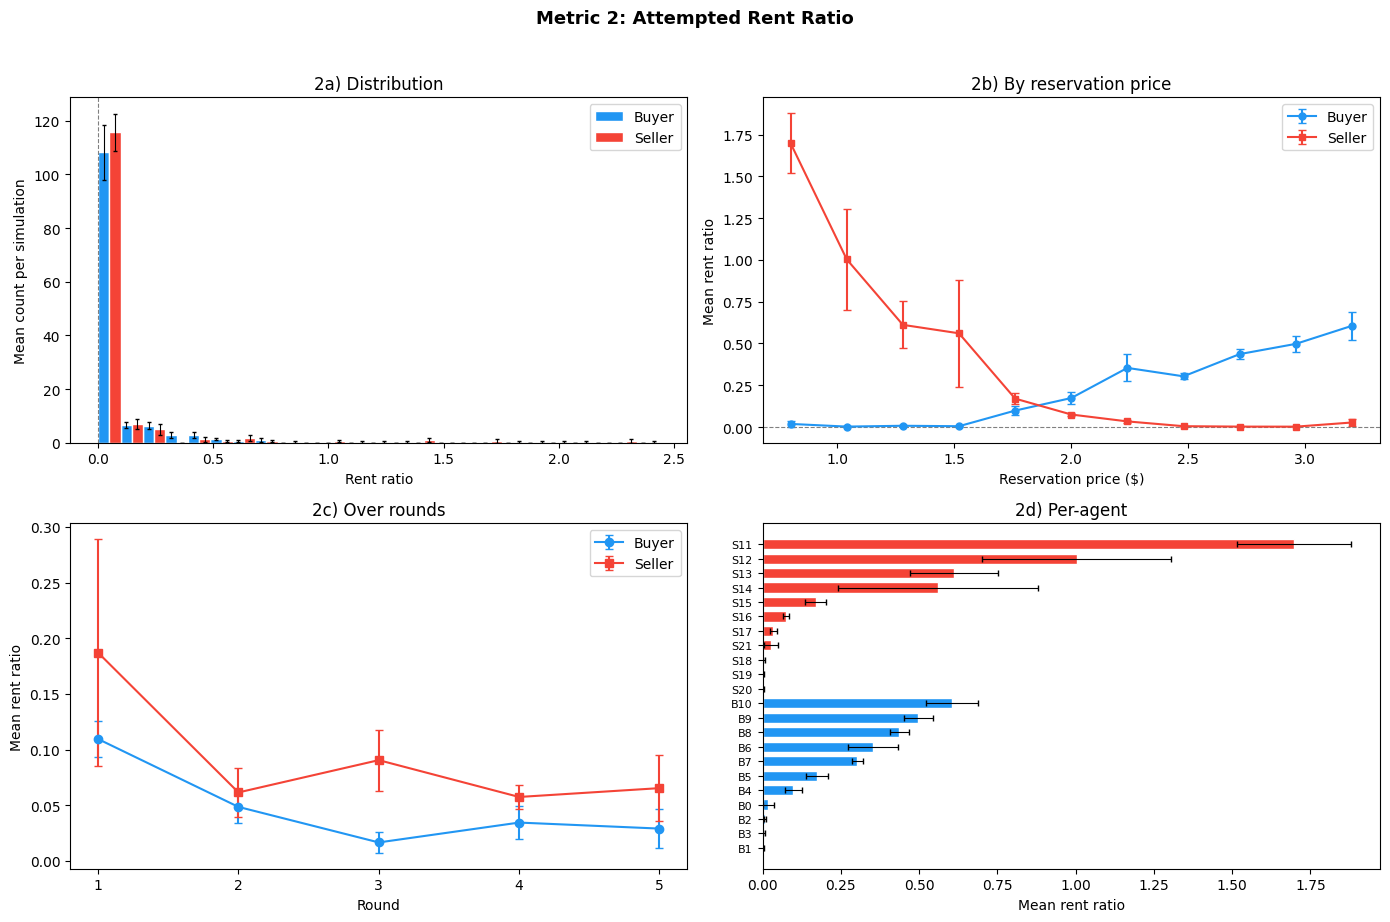

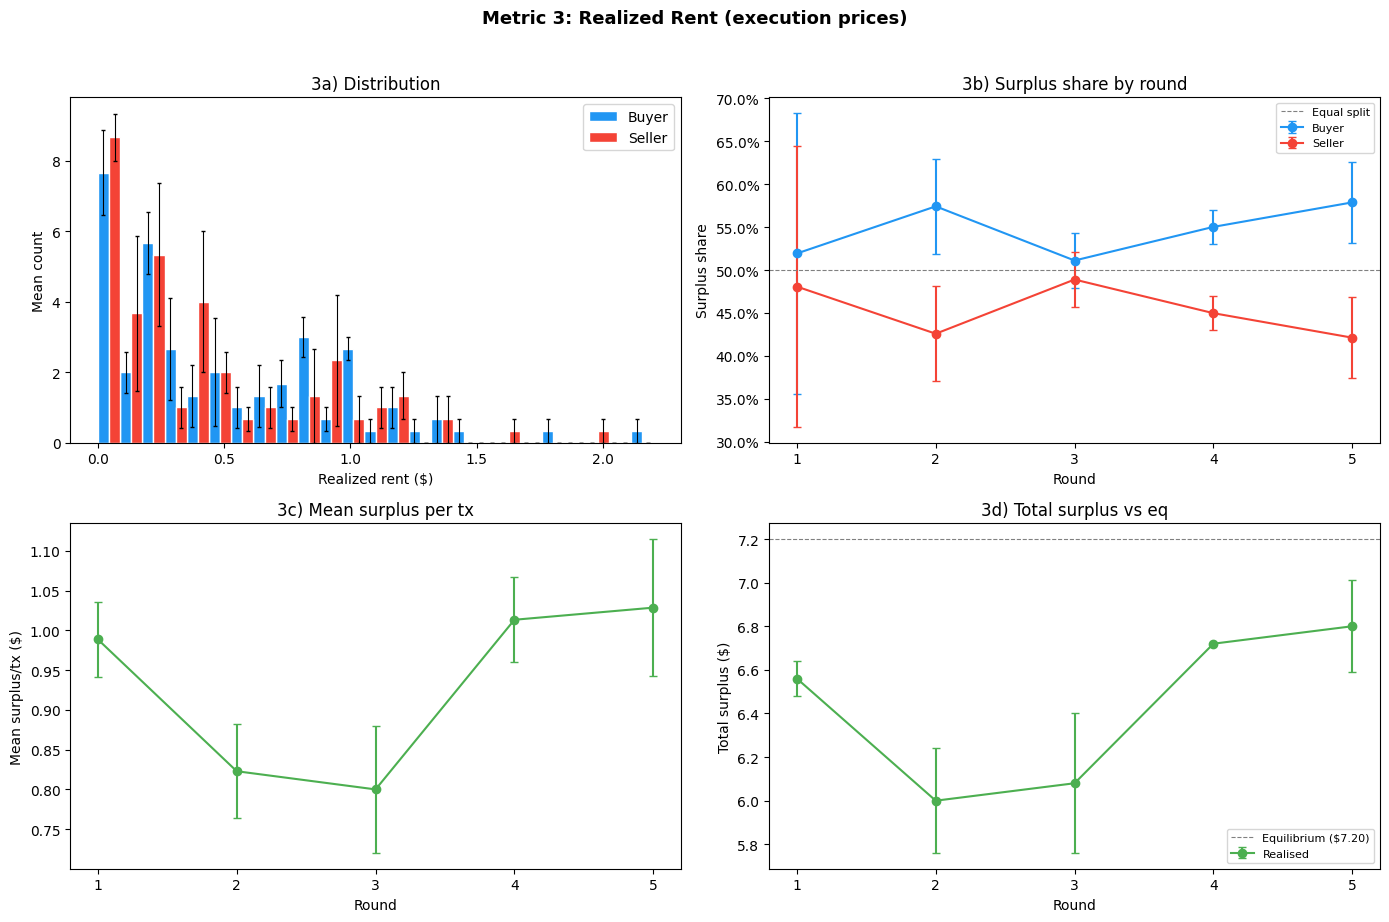

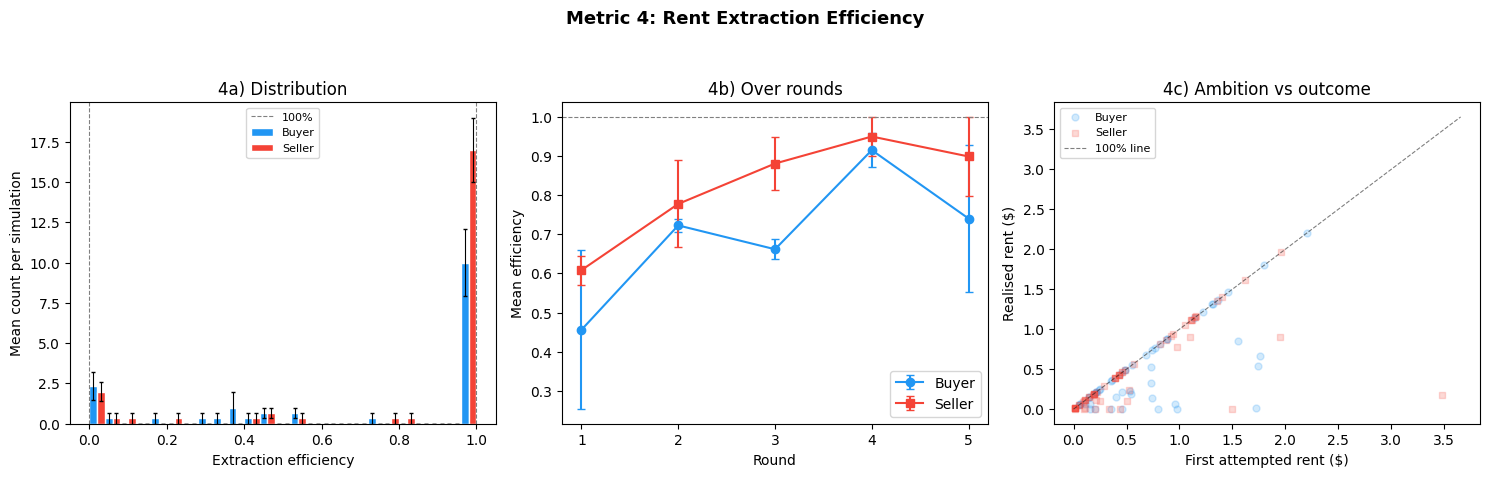

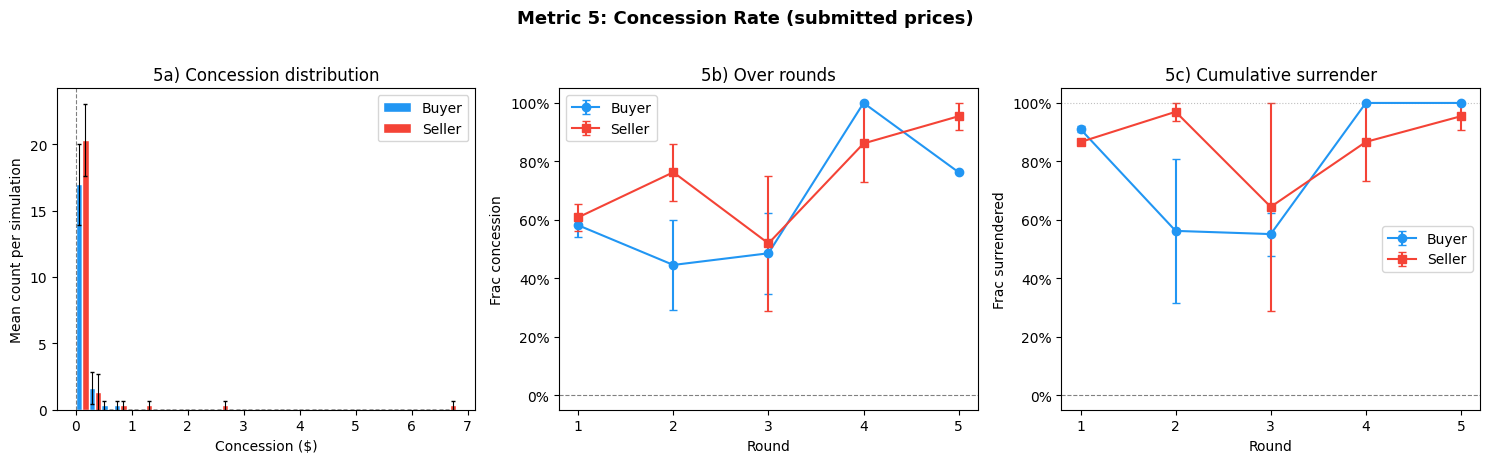

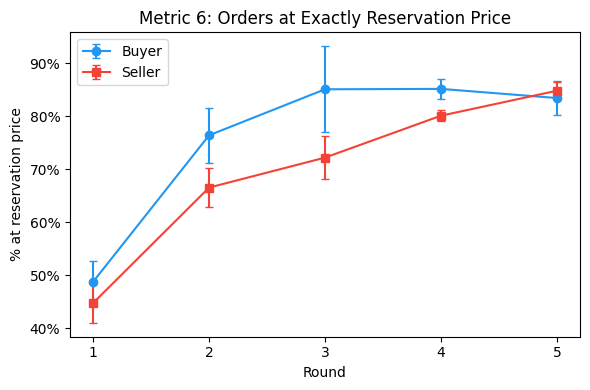

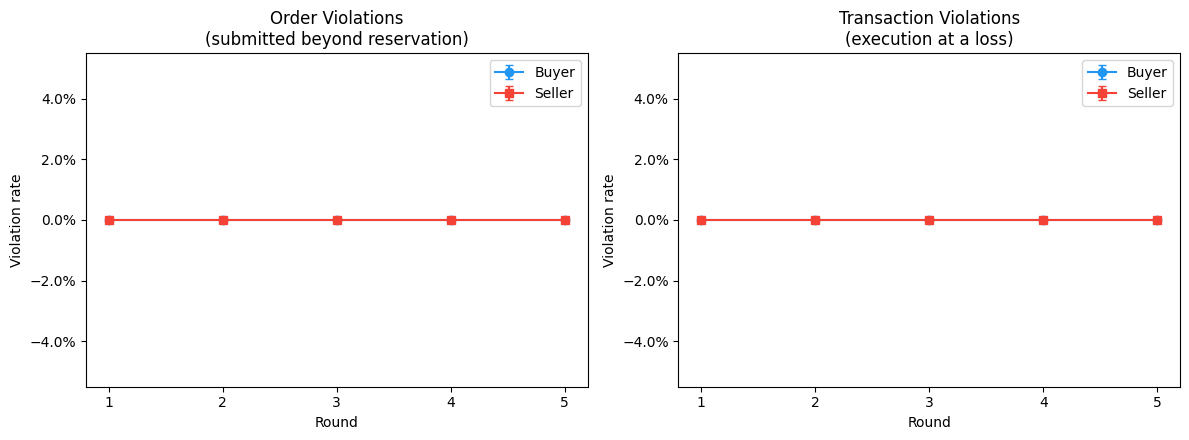

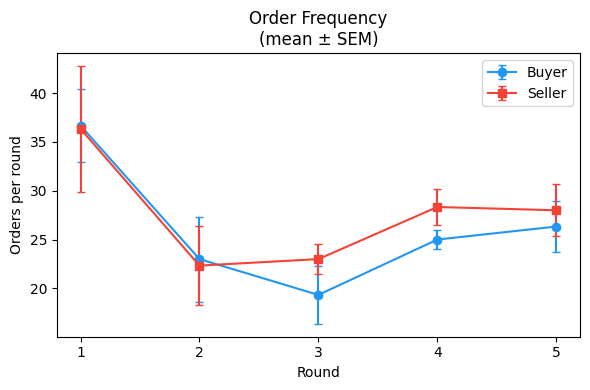

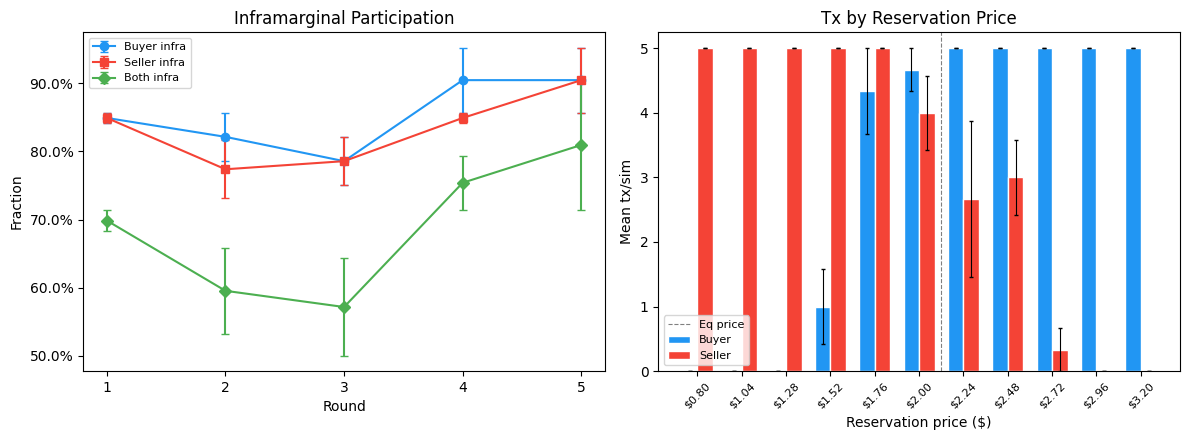

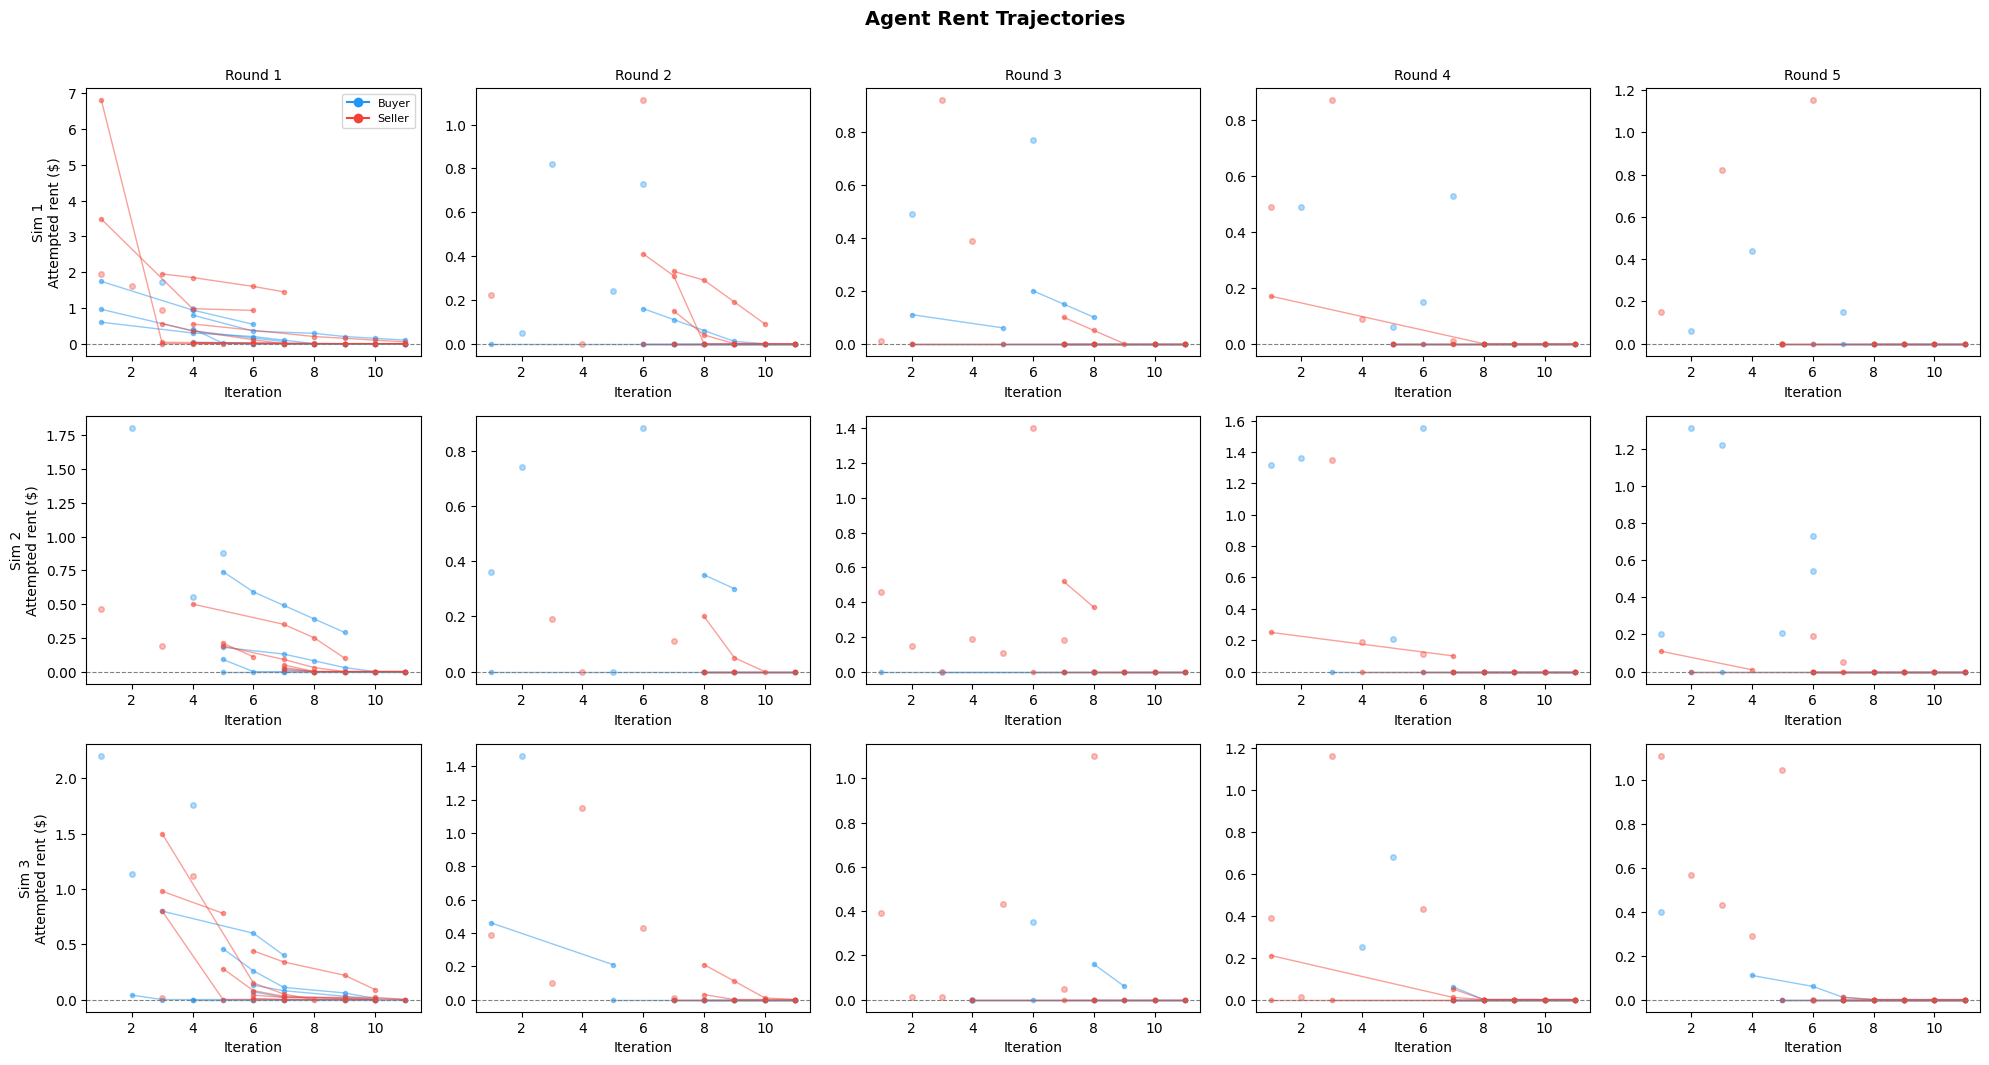

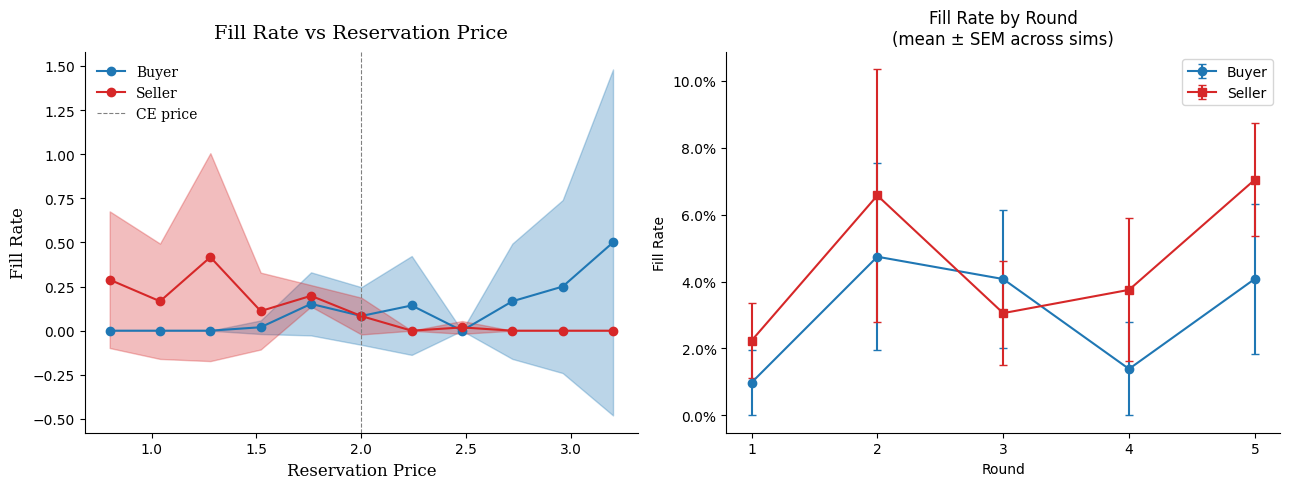

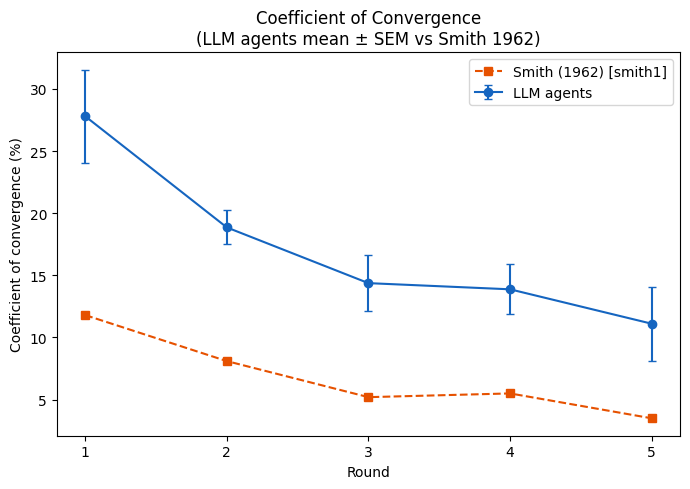

c:\Users\pauls\code\master-thesis\notebooks\results_analysis_utils.py:765: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_indices = df_plot.groupby('round').apply(lambda g: g.index.max())
c:\Users\pauls\code\master-thesis\notebooks\results_analysis_utils.py:769: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_indices = df_plot.groupby('round').apply(lambda g: g.index.min())


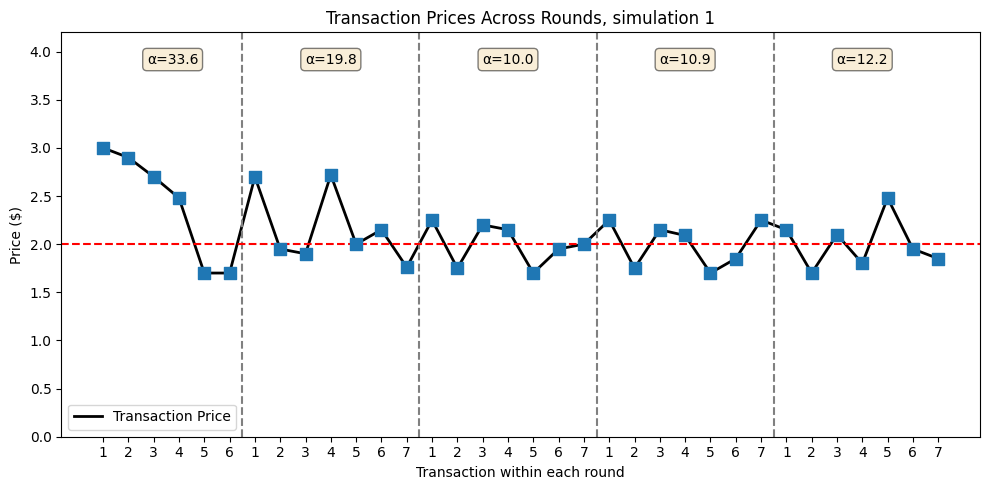

c:\Users\pauls\code\master-thesis\notebooks\results_analysis_utils.py:818: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_indices = df_plot.groupby('round').apply(lambda g: g.index.max())
c:\Users\pauls\code\master-thesis\notebooks\results_analysis_utils.py:818: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_indices = df_plot.groupby('round').apply(lambda g: g.index.max())
c:\Users\pauls\code\master-thesis\no

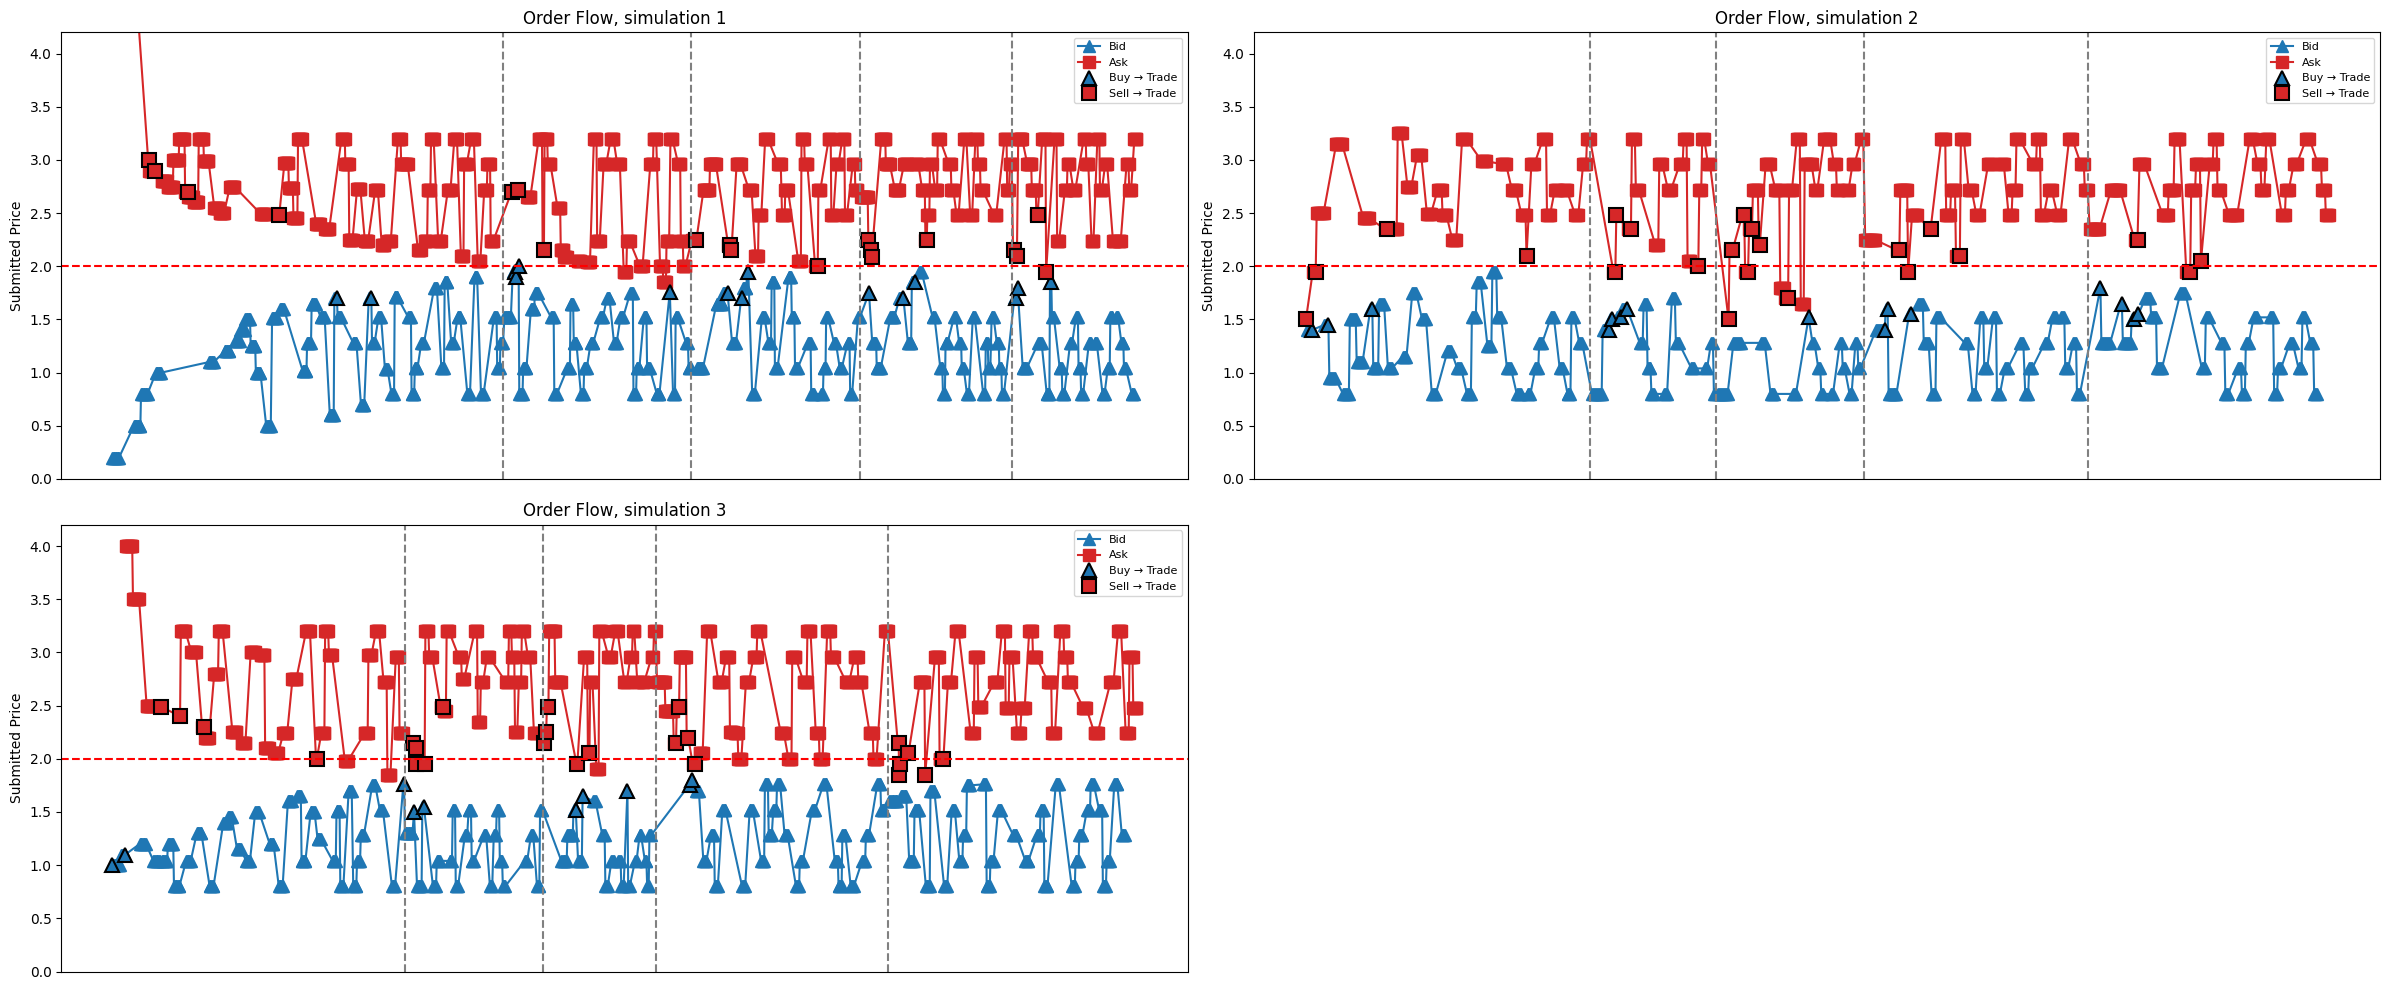

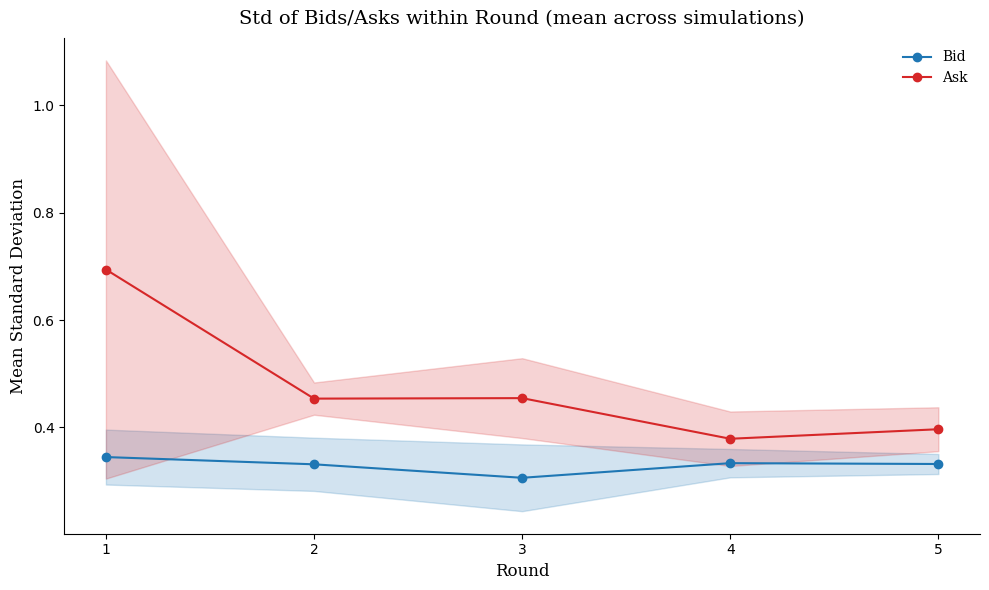

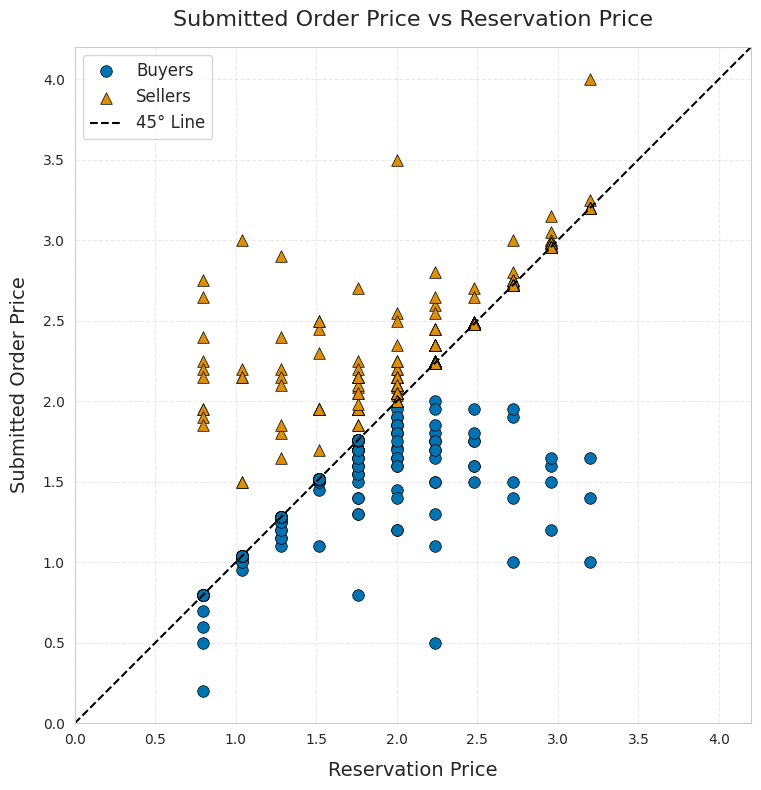


MARKET SUMMARY TABLE (Smith 1962 style)
       eq_quantity  n_trades  eq_price  mean_price   alpha  efficiency  n_extramarginal  smith_alpha
round                                                                                               
1                6     6.667       2.0       2.014  27.797       0.911            2.000         11.8
2                6     7.333       2.0       1.991  18.854       0.833            3.000          8.1
3                6     7.667       2.0       1.984  14.372       0.844            3.333          5.2
4                6     6.667       2.0       1.978  13.875       0.933            1.667          5.5
5                6     6.667       2.0       1.934  11.108       0.944            1.333          3.5


In [8]:
import yaml
from pathlib import Path
from results_analysis_utils import run_full_analysis

# experiment_id = "smith1_flash_t1_20260228_173738"
experiment_id = "smith1_pro_t1_20260228_150742"
# experiment_id = "zi_c_double_auction_20260420_172433"
# experiment_id = "zi_c_double_auction_large_20260424_220600"
independent_rounds = False  # set to True if you are testing a ZI simulation with multiple rounds (legacy)

root_path = Path(globals()['_dh'][0]).parent
results_path = root_path / 'results' / experiment_id

# read the number of simulations from the config file
with open(results_path / 'config_used.yaml', "r") as f:
    config = yaml.safe_load(f)
n_sims = config['experiment']['n_simulations']

# Single experiment
results = run_full_analysis(
    results_path, 
    n_sims, 
    config=config, 
    experiment_id=experiment_id,
    independent_rounds=independent_rounds)


# Access the DataFrames for further analysis
# df_metrics = results['metrics']      # per-round efficiency, alpha, etc.
# df_marsh = results['marshallian']    # per-transaction Marshallian path data
# eq = results['eq']                   # Equilibrium object (price, quantity, surplus, maps)